# Box plots

This example shows how box plots can be used to visualize the distribution of numerical, date and time variables.

## Includes: viz_data_quality and other libraries

In [1]:
import pandas as pd
import numpy as np
import datetime
import matplotlib as mpl
import matplotlib.pyplot as plt

from vizdataquality import calculate as vdqc, datasets as vdqd, plot as vdqp

## Get a dataframe's profile

In [2]:
# Use option to specify the data type used in this notebook
option = 3

if option == 1:
    dataset = 'numeric 1'
    column = 'Numeric percentiles'
    value_label = 'Numbers'
elif option == 2:
    dataset = 'date 1'
    column = 'Datetime percentiles'
    value_label = 'Dates'
elif option == 3:
    dataset = 'time 1'
    column = 'Datetime percentiles'
    value_label = 'Times'

num_rows, df = vdqd.get_dataset(dataset)
df_output = vdqc.calc(df)
print('Number of rows =', num_rows)
print()
print(column, '(comma-separated 0, 25, 50, 75 and 100th percentiles)')
for index, value in df_output[column].items():
    print(index, value)

Number of rows = 1000

Numeric percentiles (comma-separated 0, 25, 50, 75 and 100th percentiles)
Random 0.0013360314431104525,0.23562161400434245,0.4952935198143264,0.7543798091023514,0.9997810535106227
Normal -3.5561172112707555,-0.7237878734308391,-0.025324564273821924,0.6436724210298232,2.8911867398500566
Exponential 0.01182401716980229,2.782163714473873,6.647584739848153,13.9466500871327,83.24043463603303
Bimodal -2.9788169641640714,-0.40133600577647205,0.4357060523535303,2.5229318335568416,8.623721086884206


## Visualize the distribution of all the variables

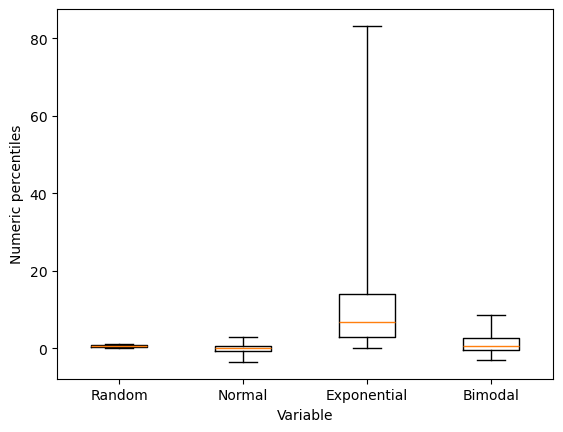

In [3]:
vdqp.boxplot(df_output[column], color='red')

## Customise the visualization

** WARNING ** vizdataquality, plot.py, _draw_fig(): Figure not output because a file with the supplied name already exists.
percentiles.jpg


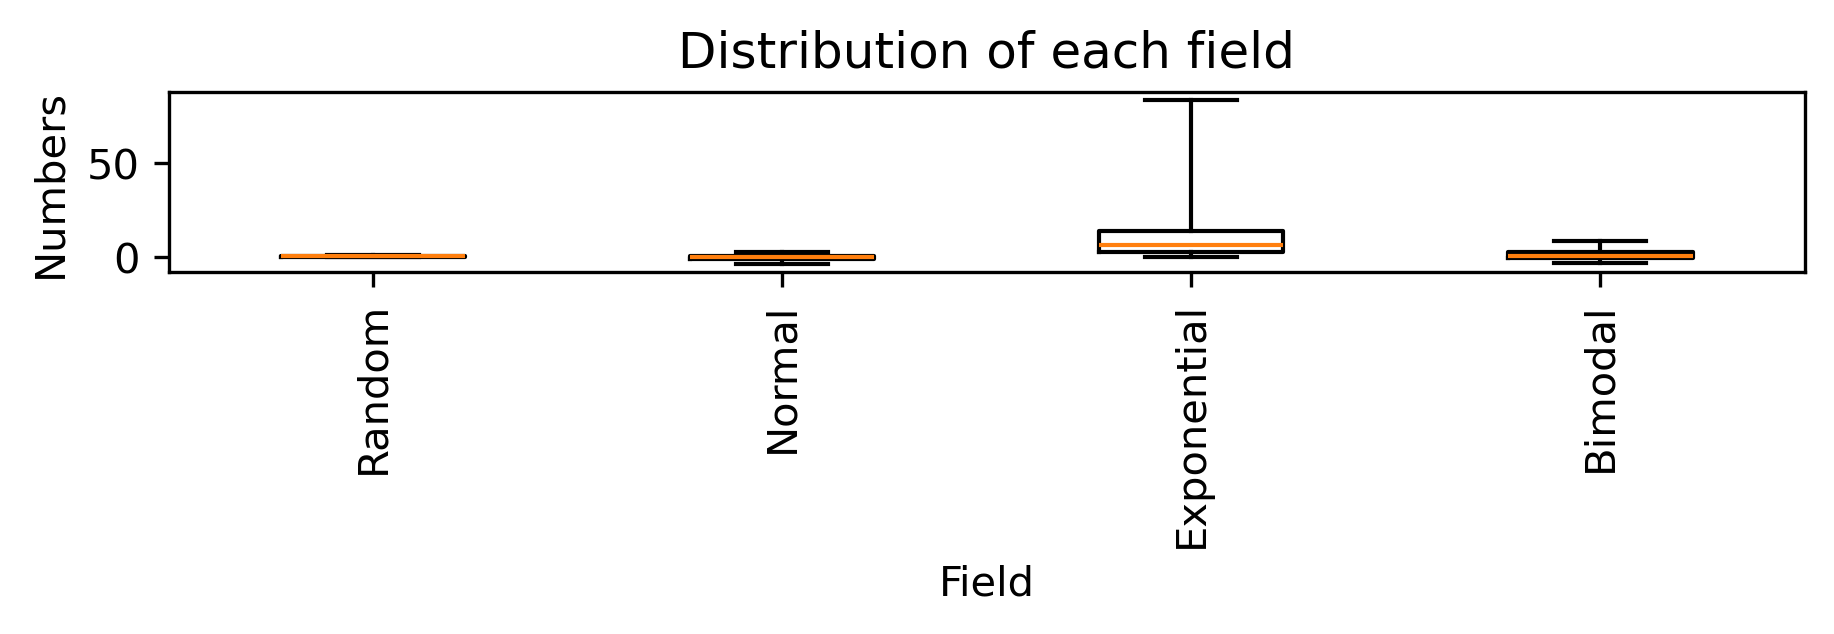

In [4]:
# A dictionary of keyword arguments that are passed to the Matplotlib Figure object
fig_kw = {'size_inches': (6, 2), 'dpi': 300, 'constrained_layout': True}
# A dictionary of keyword arguments that are passed to the Matplotlib Axes object
ax_kw = {'title': 'Distribution of each field', 'xlabel': 'Field', 'ylabel': value_label}
# A dictionary of keyword arguments that are passed to the Matplotlib bar or barh object
box_kwargs = {'color': 'orange'}
# Rotate the X axis labels, save the plot to a file and apply the keyword arguments
vdqp.boxplot(df_output[column], xlabels_rotate=90, filename='percentiles.jpg', fig_kw=fig_kw,
                ax_kw=ax_kw, **box_kwargs)

## Horizontal rather than vertical bars

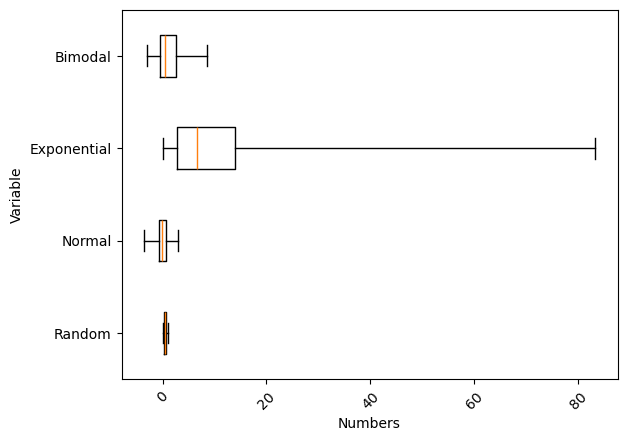

In [5]:
ax_kw = {'xlabel': value_label}
vdqp.boxplot(df_output[column], vert=False, xlabels_rotate=45, ax_kw=ax_kw)

## The variables can be divided into multiple plots (useful if there are many variables)

### Multiple rows of plots

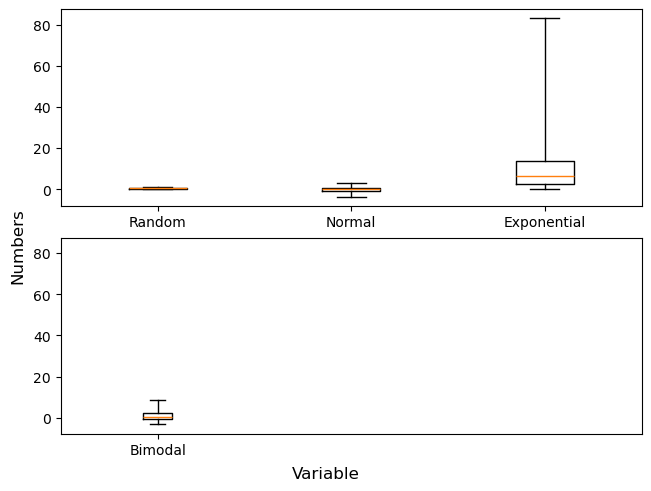

In [6]:
fig_kw = {'constrained_layout': True}
ax_kw = {'ylabel': value_label}
vdqp.multiplot('box', df_output[column], number_of_variables_per_row=3, fig_kw=fig_kw, ax_kw=ax_kw)

### Multiple columns of plots

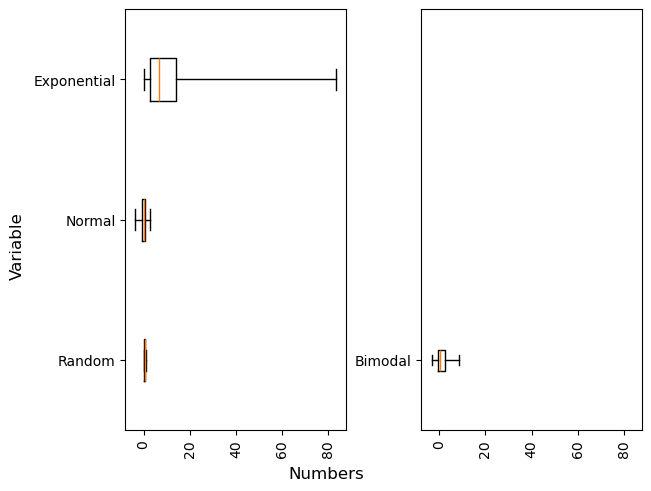

In [7]:
fig_kw = {'constrained_layout': True}
ax_kw = {'xlabel': value_label}
vdqp.multiplot('box', df_output[column], number_of_variables_per_row=3, vert=False, xlabels_rotate=90, fig_kw=fig_kw,
               ax_kw=ax_kw)